Logistic Regression:


Contributions:
1. https://www.ibm.com/think/topics/logistic-regression
2. https://www.analyticsvidhya.com/blog/2023/01/a-comprehensive-guide-to-ols-regression-part-1/

In [41]:
# Libraries:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from itertools import combinations
from sklearn.model_selection import BaseCrossValidator, ParameterGrid
from sklearn.metrics import (
    roc_auc_score, classification_report, accuracy_score,
    f1_score, recall_score, precision_score, log_loss, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os





In [42]:
# Data import and pre-processing:

# Import data:
# run script from the data_input file
#os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')
os.chdir('C:/Users/ccwis/OneDrive/Documents/1. MEng - Data Science/Project/factor_timing/data_input')

# Data import:
df_factor = pd.read_csv("labeled_relative_factor_returns.csv", parse_dates=['Date'])
df_factor = df_factor[['Date','Value_vs_Quality_trend']]    
df_factor = df_factor.set_index('Date')

df = pd.read_csv("lagged_data.csv", parse_dates=['Date'])
df = df.set_index('Date')


data = pd.concat([df,df_factor], axis=1, join='inner')
data = data.ffill()

print(data)

            VolTermStructPC1  VolTermStructPC2  MichgnConcIndx  \
Date                                                             
2007-06-18        -25.971465          9.547910            87.1   
2007-06-25        -26.283643          9.787659            87.1   
2007-07-02        -26.283553          9.942312            88.3   
2007-07-09        -28.132090          9.679810            88.3   
2007-07-16        -27.003497         10.308379            88.3   
...                      ...               ...             ...   
2025-03-03         39.101360         -6.676525            71.7   
2025-03-10         36.115275         -7.968991            71.7   
2025-03-17         35.492793         -8.161898            71.7   
2025-03-24         39.950630         -6.962702            71.7   
2025-03-31         44.421245         -5.261720            64.7   

            RandPPP_Factor_Inst_TS_ST  BCMPEBLS.Index  PPP.ZA.Index_QS  \
Date                                                               

In [43]:
"""
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4,
                 regularization="none", lambda_reg=0.0, alpha=0.5,
                 base_score=0.5):
       
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tol = tol
        self.regularization = regularization.lower()
        self.lambda_reg = lambda_reg
        self.alpha = alpha
        self.base_score = base_score

        self.beta = None
        self.cost_history = []

    def sigmoid(self, z):
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    def cost_function(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        h = np.clip(h, 1e-12, 1 - 1e-12)

        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))

        if self.regularization == "l2":
            cost += (self.lambda_reg / (2*m)) * np.sum(beta[1:] ** 2)

        elif self.regularization == "l1":
            cost += (self.lambda_reg / m) * np.sum(np.abs(beta[1:]))

        elif self.regularization == "elasticnet":
            l1_pen = self.alpha * np.sum(np.abs(beta[1:]))
            l2_pen = (1 - self.alpha) * np.sum(beta[1:] ** 2) / 2
            cost += (self.lambda_reg / m) * (l1_pen + l2_pen)

        return cost

    def compute_gradient(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        gradient = (1/m) * X.T.dot(h - y)

        if self.regularization == "l2":
            gradient[1:] += (self.lambda_reg / m) * beta[1:]

        elif self.regularization == "l1":
            gradient[1:] += (self.lambda_reg / m) * np.sign(beta[1:])

        elif self.regularization == "elasticnet":
            l1_grad = self.alpha * np.sign(beta[1:])
            l2_grad = (1 - self.alpha) * beta[1:]
            gradient[1:] += (self.lambda_reg / m) * (l1_grad + l2_grad)

        return gradient

    def gradient_descent(self, X, y, beta):
        for i in range(self.num_iterations):
            gradient = self.compute_gradient(X, y, beta)
            new_beta = beta - self.learning_rate * gradient

            change = np.linalg.norm(new_beta - beta)
            if i > 500 and change < self.tol:
                print(f"Converged after {i} iterations (Δβ={change:.2e})")
                break

            beta = new_beta
            self.cost_history.append(self.cost_function(X, y, beta))

        return beta

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        # -----------------------
        # Base score → initial bias (log-odds)
        # -----------------------
        p0 = min(max(self.base_score, 1e-5), 1 - 1e-5)
        initial_bias = np.log(p0 / (1 - p0))

        self.beta = np.zeros(X_b.shape[1])
        self.beta[0] = initial_bias  # <- initial bias from base score

        self.beta = self.gradient_descent(X_b, y, self.beta)

    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.beta))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
"""


'\nclass LogisticRegression:\n    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4,\n                 regularization="none", lambda_reg=0.0, alpha=0.5,\n                 base_score=0.5):\n\n        self.learning_rate = learning_rate\n        self.num_iterations = num_iterations\n        self.tol = tol\n        self.regularization = regularization.lower()\n        self.lambda_reg = lambda_reg\n        self.alpha = alpha\n        self.base_score = base_score\n\n        self.beta = None\n        self.cost_history = []\n\n    def sigmoid(self, z):\n        return np.where(z >= 0,\n                        1 / (1 + np.exp(-z)),\n                        np.exp(z) / (1 + np.exp(z)))\n\n    def cost_function(self, X, y, beta):\n        m = len(y)\n        h = self.sigmoid(X.dot(beta))\n        h = np.clip(h, 1e-12, 1 - 1e-12)\n\n        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))\n\n        if self.regularization == "l2":\n            cost += (self.lambda_reg

In [44]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, tol=1e-4,
                 regularization="none", lambda_reg=0.0, alpha=0.5,
                 base_score=0.5, verbose=False):
       
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.tol = tol
        self.regularization = regularization.lower()
        self.lambda_reg = lambda_reg
        self.alpha = alpha
        self.base_score = base_score
        self.verbose = verbose

        self.beta = None
        self.cost_history = []

    def sigmoid(self, z):
        return np.where(z >= 0,
                        1 / (1 + np.exp(-z)),
                        np.exp(z) / (1 + np.exp(z)))

    def cost_function(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        h = np.clip(h, 1e-12, 1 - 1e-12)

        cost = (-1/m) * np.sum(y * np.log(h) + (1-y) * np.log(1-h))

        if self.regularization == "l2":
            cost += (self.lambda_reg / (2*m)) * np.sum(beta[1:] ** 2)

        elif self.regularization == "l1":
            cost += (self.lambda_reg / m) * np.sum(np.abs(beta[1:]))

        elif self.regularization == "elasticnet":
            l1_pen = self.alpha * np.sum(np.abs(beta[1:]))
            l2_pen = (1 - self.alpha) * np.sum(beta[1:] ** 2) / 2
            cost += (self.lambda_reg / m) * (l1_pen + l2_pen)

        return cost

    def compute_gradient(self, X, y, beta):
        m = len(y)
        h = self.sigmoid(X.dot(beta))
        gradient = (1/m) * X.T.dot(h - y)

        if self.regularization == "l2":
            gradient[1:] += (self.lambda_reg / m) * beta[1:]

        elif self.regularization == "l1":
            gradient[1:] += (self.lambda_reg / m) * np.sign(beta[1:])

        elif self.regularization == "elasticnet":
            l1_grad = self.alpha * np.sign(beta[1:])
            l2_grad = (1 - self.alpha) * beta[1:]
            gradient[1:] += (self.lambda_reg / m) * (l1_grad + l2_grad)

        return gradient

    def gradient_descent(self, X, y, beta):
        for i in range(self.num_iterations):
            gradient = self.compute_gradient(X, y, beta)
            new_beta = beta - self.learning_rate * gradient

            change = np.linalg.norm(new_beta - beta)
            if i > 500 and change < self.tol:
                if self.verbose:
                    print(f"Converged after {i} iterations (Δβ={change:.2e})")
                break

            beta = new_beta
            self.cost_history.append(self.cost_function(X, y, beta))

        return beta

    def fit(self, X, y):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]

        p0 = min(max(self.base_score, 1e-5), 1 - 1e-5)
        initial_bias = np.log(p0 / (1 - p0))

        self.beta = np.zeros(X_b.shape[1])
        self.beta[0] = initial_bias
        self.beta = self.gradient_descent(X_b, y, self.beta)

    def predict_proba(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return self.sigmoid(X_b.dot(self.beta))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [45]:

# ============================================================
# Combinatorial Purged Cross-Validation (CPCV)
# ============================================================
CV_SPLITS = 5
CV_TEST_SPLITS = 1
PURGE_GAP = 12
FINAL_TEST_POINTS = 156   # 3 years of unseen data

# ===========================================================
# CPCV Splitter
# ===========================================================
class CombinatorialPurgedCV(BaseCrossValidator):
    """Purged Combinatorial Cross-Validation (De Prado style)."""
    def __init__(self, n_splits=CV_SPLITS, n_test_splits=CV_TEST_SPLITS, purge_gap=PURGE_GAP):
        self.n_splits = n_splits
        self.n_test_splits = n_test_splits
        self.purge_gap = purge_gap
    
    def split(self, X, y=None, groups=None): 
        n_samples = len(X)
        fold_size = n_samples // self.n_splits
        indices = np.arange(n_samples)

        fold_boundaries = [(i * fold_size, (i + 1) * fold_size) for i in range(self.n_splits)]
        fold_boundaries[-1] = (fold_boundaries[-1][0], n_samples)

        for test_folds in combinations(range(self.n_splits), self.n_test_splits):
            test_mask = np.zeros(n_samples, dtype=bool)
            for f in test_folds:
                s, e = fold_boundaries[f]
                test_mask[s:e] = True

            train_mask = ~test_mask
            for f in test_folds:
                s, e = fold_boundaries[f]
                train_mask[max(0, s - self.purge_gap): s] = False
                train_mask[e: min(n_samples, e + self.purge_gap)] = False

            yield indices[train_mask], indices[test_mask]

    def get_n_splits(self, X=None, y=None, groups=None):
        from math import comb
        return comb(self.n_splits, self.n_test_splits)




In [46]:
"""
# ===========================================================
# CPCV Hyperparameter Tuning
# ===========================================================
def tune_hyperparameters(X, y):
    cv = CombinatorialPurgedCV()
    param_grid = {
        "learning_rate": [0.01, 0.05, 0.1],
        "num_iterations": [500, 1000, 2000],
        #"tol": [1e-3, 1e-4, 1e-5],
        "alpha": [0.0, 0.5, 1],
        "lambda_reg": [0.0, 0.01, 0.1],
        "base_score":[0.5,0.6,0.7]
    }

    best_score, best_params = -np.inf, None
    results = []

    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")
    for params in ParameterGrid(param_grid):
        fold_scores = []
        for train_idx, test_idx in cv.split(X, y):
            model = LogisticRegression(**params)
            model.fit(X[train_idx], y[train_idx])
            y_pred = model.predict(X[test_idx])
            score = roc_auc_score(y[test_idx], y_pred)
            fold_scores.append(score)

        mean_score = np.mean(fold_scores)
        results.append((params, mean_score))
        if mean_score > best_score:
            best_score, best_params = mean_score, params
            print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    results.sort(key=lambda x: x[1], reverse=True)
    print("\n=== Top 5 Parameter Combinations ===")
    for params, score in results[:5]:
        print(f"Score: {score:.3f} | Params: {params}")

    return best_params
"""

'\n# ===========================================================\n# CPCV Hyperparameter Tuning\n# ===========================================================\ndef tune_hyperparameters(X, y):\n    cv = CombinatorialPurgedCV()\n    param_grid = {\n        "learning_rate": [0.01, 0.05, 0.1],\n        "num_iterations": [500, 1000, 2000],\n        #"tol": [1e-3, 1e-4, 1e-5],\n        "alpha": [0.0, 0.5, 1],\n        "lambda_reg": [0.0, 0.01, 0.1],\n        "base_score":[0.5,0.6,0.7]\n    }\n\n    best_score, best_params = -np.inf, None\n    results = []\n\n    print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")\n    for params in ParameterGrid(param_grid):\n        fold_scores = []\n        for train_idx, test_idx in cv.split(X, y):\n            model = LogisticRegression(**params)\n            model.fit(X[train_idx], y[train_idx])\n            y_pred = model.predict(X[test_idx])\n            score = roc_auc_score(y[test_idx], y_pred)\n            fold_scores.append

In [47]:
def tune_hyperparameters(X, y, return_grid=False, verbose=True):
    cv = CombinatorialPurgedCV()

    param_grid = {
        "learning_rate": [0.01, 0.05, 0.1],
        "num_iterations": [500, 1000, 2000],
        "alpha": [0.0, 0.5, 1],
        "lambda_reg": [0.0, 0.01, 0.1],
        "base_score": [0.5, 0.6, 0.7],
        "regularization": ["elasticnet"]
    }

    best_score, best_params = -np.inf, None
    rows = []

    if verbose:
        print(f"Testing {len(ParameterGrid(param_grid))} parameter combinations...")

    for params in ParameterGrid(param_grid):
        fold_aucs = []

        for train_idx, test_idx in cv.split(X, y):
            model = LogisticRegression(**params, verbose=False)
            model.fit(X[train_idx], y[train_idx])

            y_score = model.predict_proba(X[test_idx])
            auc = roc_auc_score(y[test_idx], y_score)
            fold_aucs.append(float(auc))

        mean_auc = np.mean(fold_aucs)
        std_auc = np.std(fold_aucs, ddof=1)

        rows.append({
            **params,
            "mean_auc": mean_auc,
            "std_auc": std_auc,
            "min_auc": np.min(fold_aucs),
            "max_auc": np.max(fold_aucs),
            "fold_aucs": fold_aucs
        })

        if mean_auc > best_score:
            best_score, best_params = mean_auc, params
            if verbose:
                print(f"New best params: {best_params} (AUC: {best_score:.3f})")

    grid_df = pd.DataFrame(rows).sort_values("mean_auc", ascending=False)

    if verbose:
        print("\n=== Top 5 Parameter Combinations ===")
        for _, r in grid_df.head(5).iterrows():
            print(f"Score: {r['mean_auc']:.3f} | Params: {best_params}")

    if return_grid:
        return best_params, grid_df
    return best_params

In [48]:
import hashlib

def window_signature(X):
    """
    Create a stable, compact signature for a rolling window
    based on its mean and std across features.
    """
    stats = np.concatenate([X.mean(axis=0), X.std(axis=0)])
    stats_bytes = stats.tobytes()
    return hashlib.sha1(stats_bytes).hexdigest()

In [49]:
from pathlib import Path
import pickle
import json

def save_artifact(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if isinstance(obj, pd.DataFrame):
        obj.to_csv(path, index=False)
    elif path.suffix == ".json":
        with open(path, "w") as f:
            json.dump(obj, f, indent=2)
    else:
        with open(path, "wb") as f:
            pickle.dump(obj, f)

In [50]:
def walk_forward_validation(
    X, y, n_test, base_params,
    retune_every=52, lookback=749
):
    actuals, predictions, probabilities = [], [], []
    current_params = base_params.copy()

    hyperparam_cache = {}  

    print(f"\nRunning Rolling-Window WFV with Hyperparameter Caching...")
    print(f"Lookback window = {lookback} samples")

    for i in tqdm(range(n_test)):
        train_size = len(X) - n_test + i
        if train_size <= 0:
            continue

        # === Rolling window ===
        start = max(0, train_size - lookback)
        X_train = X[start:train_size]
        y_train = y[start:train_size]
        X_test  = X[train_size:train_size+1]
        y_test  = y[train_size:train_size+1]

        # === Adaptive tuning with caching ===
        if retune_every and i > 0 and i % retune_every == 0:

            # create stable signature of training window
            sig = window_signature(X_train)

            if sig in hyperparam_cache:
                print(f"\nReusing cached params at step {i}")
                current_params = hyperparam_cache[sig]

            else:
                print(f"\n--- Retuning at step {i} ---")
                current_params = tune_hyperparameters(X_train, y_train)

                hyperparam_cache[sig] = current_params

        # Train model
        model = LogisticRegression(**current_params)
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)

        predictions.append(y_pred[0])
        actuals.append(y_test[0])
        probabilities.append(y_prob[0])

    print("\n=== Final Evaluation Results ===")
    print(classification_report(actuals, predictions))
    return (
        np.array(actuals),
        np.array(predictions),
        np.array(probabilities)
    )


In [51]:
# ===========================================================
# Results graph
# ===========================================================
def display_walkforward_results(y_true, y_pred, y_proba=None):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)

    print("Walk-forward Performance:")
    print(f"Accuracy : {acc:.3f}")
    print(f"F1 Score : {f1:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"Precision: {prec:.3f}")

    if y_proba is not None:
        auc    = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)

        # ==== FIXED LOG LOSS ====
        y_proba_clipped = np.clip(y_proba, 1e-12, 1 - 1e-12)
        ll = log_loss(y_true, y_proba_clipped)

        print(f"ROC AUC  : {auc:.3f}")
        print(f"PR  AUC  : {pr_auc:.3f}")
        print(f"Log Loss : {ll:.3f}")

    # --- Graphs ---
    plt.figure(figsize=(12,5))
    plt.plot(y_true, label="True", marker="o",linestyle='None')
    plt.plot(y_pred, label="Predicted", marker="x",linestyle='None')
    plt.plot(y_proba,label="Probability",linestyle='--', alpha=0.5)
    plt.title("Walk-forward Predictions vs True Values")
    plt.legend()
    plt.show()

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
        plt.plot([0,1],[0,1], '--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()

        precs, recs, _ = precision_recall_curve(y_true, y_proba)
        plt.figure(figsize=(6,6))
        plt.plot(recs, precs, label=f"PR (AP={pr_auc:.3f})", color="purple")
        plt.legend()
        plt.show()

        cm = confusion_matrix(y_true, y_pred)
        ConfusionMatrixDisplay(cm).plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()



In [52]:
"""
def main():
    # Data prep:
    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    # Recover NaNs + scale
    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # === PHASE 1: HYPERPARAMETER TUNING (initial) ===
    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params = tune_hyperparameters(X_scaled, y)

    # === PHASE 2: ADAPTIVE WALK-FORWARD ONLY ===
    print("\n=== PHASE 2: ADAPTIVE WALK-FORWARD (ONLY) ===")
    actuals, preds, probs = walk_forward_validation(
        X_scaled, y,
        n_test=FINAL_TEST_POINTS,
        base_params=best_params,
        retune_every=52     # Only adaptive mode
    )

    # === PHASE 3: RESULTS ===
    display_walkforward_results(actuals, preds, probs)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "adaptive": (actuals, preds, probs),
    }


if __name__ == "__main__":
    results = main()
"""

'\ndef main():\n    # Data prep:\n    X = data.iloc[:, :-1].values\n    y = data.iloc[:, -1].values\n    feature_names = data.columns[:-1].tolist()\n\n    # Recover NaNs + scale\n    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)\n    scaler = StandardScaler()\n    X_scaled = scaler.fit_transform(X)\n\n    # === PHASE 1: HYPERPARAMETER TUNING (initial) ===\n    print("=== PHASE 1: HYPERPARAMETER TUNING ===")\n    best_params = tune_hyperparameters(X_scaled, y)\n\n    # === PHASE 2: ADAPTIVE WALK-FORWARD ONLY ===\n    print("\n=== PHASE 2: ADAPTIVE WALK-FORWARD (ONLY) ===")\n    actuals, preds, probs = walk_forward_validation(\n        X_scaled, y,\n        n_test=FINAL_TEST_POINTS,\n        base_params=best_params,\n        retune_every=52     # Only adaptive mode\n    )\n\n    # === PHASE 3: RESULTS ===\n    display_walkforward_results(actuals, preds, probs)\n\n    return {\n        "best_params": best_params,\n        "feature_names": feature_names,\n        "adaptive": 

In [53]:
def main():

    X = data.iloc[:, :-1].values
    y = data.iloc[:, -1].values
    feature_names = data.columns[:-1].tolist()

    X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    print("=== PHASE 1: HYPERPARAMETER TUNING ===")
    best_params, tuning_grid = tune_hyperparameters(X_scaled, y, return_grid=True)

    save_artifact(tuning_grid, "artifacts/logistic_tuning_grid.pkl")
    save_artifact(best_params, "artifacts/logistic_best_params.json")

    print("\n=== PHASE 2: ADAPTIVE WALK-FORWARD ===")
    actuals, preds, probs = walk_forward_validation(
        X_scaled, y,
        n_test=FINAL_TEST_POINTS,
        base_params=best_params,
        retune_every=52
    )

    display_walkforward_results(actuals, preds, probs)

    return {
        "best_params": best_params,
        "feature_names": feature_names,
        "adaptive": (actuals, preds, probs),
        "tuning_grid": tuning_grid 
    }

if __name__ == "__main__":
    results = main()

=== PHASE 1: HYPERPARAMETER TUNING ===
Testing 243 parameter combinations...
New best params: {'alpha': 0.0, 'base_score': 0.5, 'lambda_reg': 0.0, 'learning_rate': 0.01, 'num_iterations': 500, 'regularization': 'elasticnet'} (AUC: 0.552)
New best params: {'alpha': 0.0, 'base_score': 0.5, 'lambda_reg': 0.01, 'learning_rate': 0.01, 'num_iterations': 500, 'regularization': 'elasticnet'} (AUC: 0.552)


KeyboardInterrupt: 

In [ ]:

actuals = results["adaptive"][0]
preds   = results["adaptive"][1]
probs   = results["adaptive"][2]


df_probs = pd.DataFrame({
    "Date": data.index[-len(probs):],
    "actual": actuals,
    "prediction": preds,
    "probability": probs
}).set_index("Date")


In [ ]:
df_probs.to_csv('log_value_quality_probs.csv',index=True)

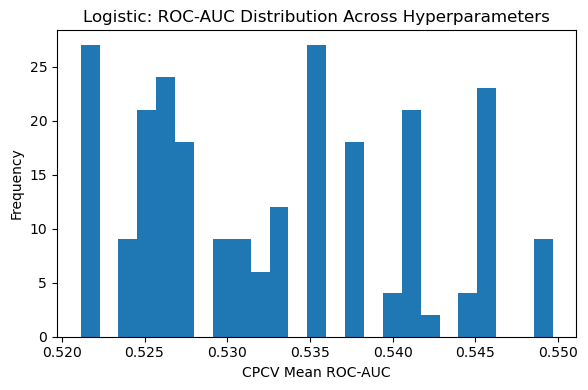

In [ ]:
import pickle
tuning_grid = results["tuning_grid"]

plt.figure(figsize=(6,4))
plt.hist(tuning_grid["mean_auc"], bins=25)
plt.xlabel("CPCV Mean ROC-AUC")
plt.ylabel("Frequency")
plt.title("Logistic: ROC-AUC Distribution Across Hyperparameters")
plt.tight_layout()
plt.show()

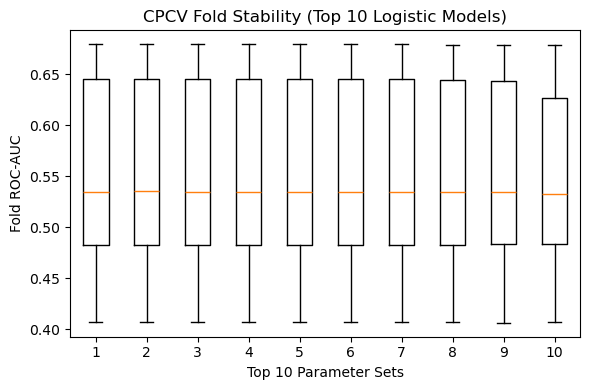

In [ ]:
top10 = tuning_grid.head(10)

fold_data = top10["fold_aucs"].tolist()

plt.figure(figsize=(6,4))
plt.boxplot(fold_data)
plt.xlabel("Top 10 Parameter Sets")
plt.ylabel("Fold ROC-AUC")
plt.title("CPCV Fold Stability (Top 10 Logistic Models)")
plt.tight_layout()
plt.show()

In [ ]:
import shap 

# -----------------------------
# Data
# -----------------------------
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values
feature_names = results["feature_names"]

X = np.nan_to_num(X, nan=np.nan, posinf=1e10, neginf=-1e10)

train_end = len(X) - FINAL_TEST_POINTS
X_train = X[:train_end]
y_train = y[:train_end]

# -----------------------------
# Scale (as you do in main)
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# -----------------------------
# Fit custom logistic regression
# -----------------------------
bp = results["best_params"]  # your dict
model = LogisticRegression(
    learning_rate=bp["learning_rate"],
    num_iterations=bp["num_iterations"],
    lambda_reg=bp["lambda_reg"],
    alpha=bp["alpha"],
    base_score=bp["base_score"],
    regularization="none" if bp["lambda_reg"] == 0 else "elasticnet" if bp["alpha"] > 0 else "l2"
)
model.fit(X_train_scaled, y_train)

# -----------------------------
# Extract betas (exclude intercept)
# -----------------------------
betas = model.beta[1:]   # shape (n_features,)
intercept = model.beta[0]

# -----------------------------
# SHAP-consistent contributions in log-odds space
# baseline-centred on training distribution
# -----------------------------
X_bg = X_train_scaled
x_mean = X_bg.mean(axis=0)  # E[X] on background

# phi_ij = (x_ij - E[x_j]) * beta_j
phi = (X_train_scaled - x_mean) * betas  # (n_samples, n_features)

# Expected value (baseline) in log-odds space
expected_value = intercept + np.dot(x_mean, betas)

# Global importance
importance_shap = pd.Series(
    np.abs(phi).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print("\n=== Custom Logistic SHAP Global Importance (Mean |phi|, log-odds) ===")
print(importance_shap.head(20))

# Optional sanity check: reconstruct raw score z
z_recon = expected_value + phi.sum(axis=1)

# Compare with model's own raw scores:
# raw score = X_b dot beta, where X_b includes intercept column
X_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
z_model = X_b.dot(model.beta)

print("\nMax |reconstruction error|:", np.max(np.abs(z_recon - z_model)))




=== Custom Logistic SHAP Global Importance (Mean |phi|, log-odds) ===
ZAR18M.Curncy_QS                         0.864006
RandPPP_Factor_Inst_TS_ST                0.843851
SA_RB_Curvature                          0.795837
MichgnConcIndx                           0.699739
USDZAR_EntDyn                            0.677947
SA_NB_Slope                              0.604686
JALSH.Index.Price.to.Sales.Ratio_Diff    0.490406
GlobalPropertyVol12                      0.431930
GenComIndexPC1_QS                        0.368291
zrel_value_vs_quality_12                 0.345893
US_RB_Curvature                          0.329430
MXWD.Index.PE.Ratio_QS                   0.301309
TOP40.Index.Price.to.Book.Ratio_Diff     0.286166
relvol_momentum_vs_quality_12            0.280580
USDZARV1M.Curncy_QS                      0.270575
USDZARV1Y.Curncy_QS                      0.253075
GLD_RollSD                               0.223025
corr_momentum_value_12                   0.216894
zrel_momentum_vs_quality_12  

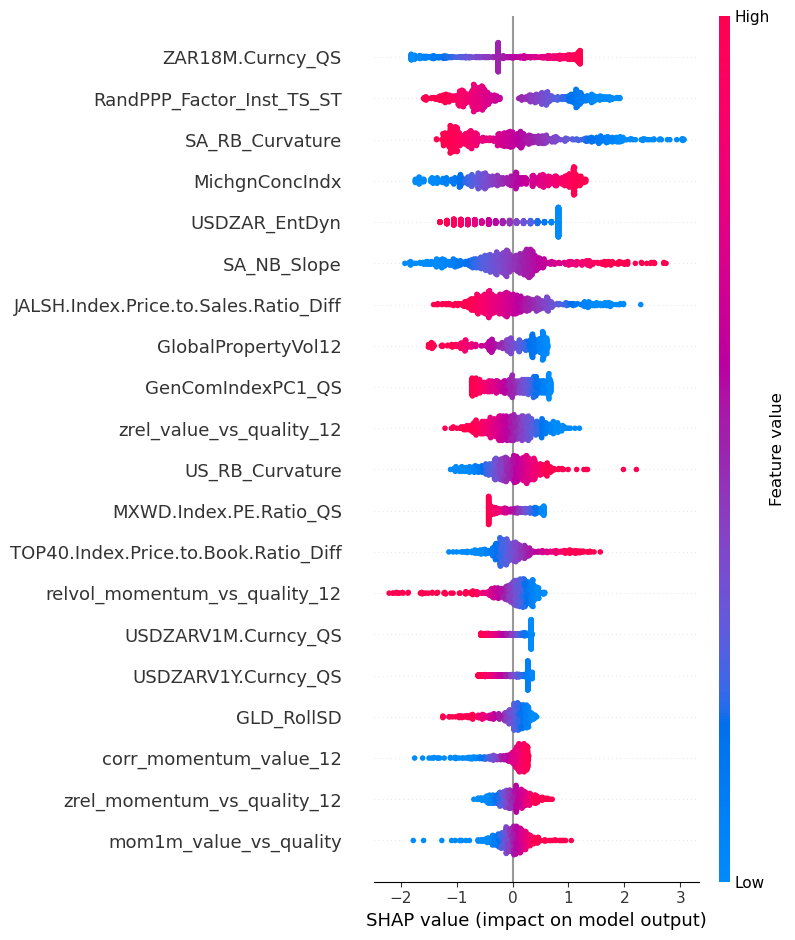

In [ ]:


# phi: (n_samples, n_features)
# expected_value: scalar baseline in log-odds
# X_train_scaled: (n_samples, n_features)

exp = shap.Explanation(
    values=phi,
    base_values=np.full(phi.shape[0], expected_value),
    data=X_train_scaled,
    feature_names=feature_names
)

shap.summary_plot(exp, X_train_scaled, feature_names=feature_names, plot_type="dot")


In [ ]:
log_shap = importance_shap.head(20)
log_shap.to_csv('log_shap.csv',index=True)